# 02 — Model Training: Dutch Day-Ahead Price Forecasting

LightGBM point forecast + p10/p90 quantile regression trained on 2021–2024, validated on 2024, evaluated on the held-out 2025 test set.

## Section 1 — Setup and Data Loading

Load both feature parquets. Print shapes, date ranges, and confirm zero NaN in the test set. Drop the first 168 rows from the training set: these are the lag warm-up rows where `price_lag_168h` (and other lags) are NaN because there is no data 168 hours before 2021-01-01. Report how many training rows remain.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Resolve project root (notebook sits at ML_model/notebooks/, two levels up)
PROJECT_ROOT = Path().resolve().parent.parent
FEATURES = PROJECT_ROOT / 'Data'      / 'features'
PLOTS    = PROJECT_ROOT / 'Analytics' / 'plots'
MODELS   = PROJECT_ROOT / 'ML_model'  / 'models'
EVALS    = PROJECT_ROOT / 'ML_model'  / 'evaluations'

for p in (PLOTS, MODELS, EVALS):
    p.mkdir(parents=True, exist_ok=True)

train_raw = pd.read_parquet(FEATURES / 'features_train.parquet')
test      = pd.read_parquet(FEATURES / 'features_test.parquet')

print("=" * 65)
print("RAW DATA")
print("=" * 65)
print(f"Train raw : {train_raw.shape[0]:,} rows x {train_raw.shape[1]} cols")
print(f"  Range   : {train_raw.index.min()} -> {train_raw.index.max()}")
print(f"  NaN     : {train_raw.isna().sum().sum():,} cells")
print()
print(f"Test      : {test.shape[0]:,} rows x {test.shape[1]} cols")
print(f"  Range   : {test.index.min()} -> {test.index.max()}")
print(f"  NaN     : {test.isna().sum().sum():,} cells  <- confirmed zero")

train    = train_raw.dropna()
n_dropped = len(train_raw) - len(train)
print(f"\nDropped {n_dropped} warm-up rows (lag/rolling NaN at series start)")
print(f"Training rows remaining: {len(train):,}")


RAW DATA
Train raw : 35,064 rows x 36 cols
  Range   : 2021-01-01 00:00:00+00:00 -> 2024-12-31 23:00:00+00:00
  NaN     : 244 cells

Test      : 8,759 rows x 36 cols
  Range   : 2025-01-01 00:00:00+00:00 -> 2025-12-31 22:00:00+00:00
  NaN     : 0 cells  <- confirmed zero

Dropped 168 warm-up rows (lag/rolling NaN at series start)
Training rows remaining: 34,896


## Section 2 — Train/Validation Split

**Why we never use a random split for time series data:**

Electricity prices exhibit strong temporal autocorrelation (today's price depends heavily on yesterday's via the lag features), daily/weekly/annual seasonality, and non-stationary structural trends (renewable buildout, fuel price regimes). A random split scatters future data points into the training set, allowing the model to 'see the future' — a form of data leakage. The model would appear accurate on the shuffled validation set but fail in deployment. We use a strict chronological split: 2021–2023 trains the model, 2024 is the validation fold, 2025 is the completely held-out test set that is never touched until the final evaluation.

In [2]:
TARGET      = 'price_eur_kwh'
FEATURE_COLS = [c for c in train.columns if c != TARGET]

train_set = train[train.index.year <= 2023]
val_set   = train[train.index.year == 2024]

X_train, y_train = train_set[FEATURE_COLS], train_set[TARGET]
X_val,   y_val   = val_set[FEATURE_COLS],   val_set[TARGET]
X_test,  y_test  = test[FEATURE_COLS],      test[TARGET]

print("=" * 65)
print("SPLIT SIZES")
print("=" * 65)
print(f"Train (2021-2023) : {len(train_set):,} rows  "
      f"{train_set.index.min().date()} -> {train_set.index.max().date()}")
print(f"Val   (2024)      : {len(val_set):,} rows  "
      f"{val_set.index.min().date()} -> {val_set.index.max().date()}")
print(f"Test  (2025)      : {len(test):,} rows  "
      f"{test.index.min().date()} -> {test.index.max().date()}")
print(f"\nFeature columns: {len(FEATURE_COLS)}")


SPLIT SIZES
Train (2021-2023) : 26,112 rows  2021-01-08 -> 2023-12-31
Val   (2024)      : 8,784 rows  2024-01-01 -> 2024-12-31
Test  (2025)      : 8,759 rows  2025-01-01 -> 2025-12-31

Feature columns: 35


## Section 3 — Train the Point Forecast Model

Train a LightGBM regressor (squared-error loss, MSE) with early stopping on the 2024 validation set. Parameters are set for moderate depth (`num_leaves=63`), mild regularisation via row and column subsampling, and a conservative learning rate that allows early stopping to find the right number of trees.

In [3]:
import lightgbm as lgb

base_params = dict(
    n_estimators       = 1000,
    learning_rate      = 0.05,
    num_leaves         = 63,
    min_child_samples  = 20,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    early_stopping_rounds = 50,
    verbose            = -1,
    random_state       = 42,
)

print("Training point forecast model (LightGBM, MSE loss)...")
model_point = lgb.LGBMRegressor(**base_params)
model_point.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
)
print(f"Training complete. Trees used after early stopping: {model_point.best_iteration_}")


Training point forecast model (LightGBM, MSE loss)...


Training complete. Trees used after early stopping: 337


## Section 4 — Train the Quantile Models (p10 / p90)

Two additional LightGBM models trained with quantile loss: one at the 10th percentile (p10, lower bound of the interval) and one at the 90th percentile (p90, upper bound). Together with the point forecast they form an 80% prediction interval. The battery optimizer in Part 2 will use the interval width to gauge price uncertainty before committing to a charge/discharge schedule.

In [4]:
quantile_params = {**base_params, 'objective': 'quantile'}

print("Training p10 model (alpha=0.10)...")
model_p10 = lgb.LGBMRegressor(**quantile_params, alpha=0.10)
model_p10.fit(X_train, y_train, eval_set=[(X_val, y_val)])
print(f"  Trees used (p10): {model_p10.best_iteration_}")

print("\nTraining p90 model (alpha=0.90)...")
model_p90 = lgb.LGBMRegressor(**quantile_params, alpha=0.90)
model_p90.fit(X_train, y_train, eval_set=[(X_val, y_val)])
print(f"  Trees used (p90): {model_p90.best_iteration_}")

# Save models
model_point.booster_.save_model(str(MODELS / 'lgbm_point.txt'))
model_p10.booster_.save_model(str(MODELS / 'lgbm_p10.txt'))
model_p90.booster_.save_model(str(MODELS / 'lgbm_p90.txt'))
print(f"\nModels saved to {MODELS}")


Training p10 model (alpha=0.10)...


  Trees used (p10): 97

Training p90 model (alpha=0.90)...


  Trees used (p90): 407

Models saved to /Users/marijacveevska/Developer/epex_battery_forecast_and_optimization/ML_model/models


## Section 5 — Validation Set Metrics (2024)

Evaluate all three models on the 2024 validation set. Metrics: **MAE** (mean absolute error), **RMSE** (root mean squared error), **MAPE** (mean absolute percentage error — hours with |actual| < 0.001 EUR/kWh excluded to avoid division by near-zero), and **directional accuracy** (fraction of consecutive-hour price moves where the sign of the predicted change matches the actual sign). Then two plots: January 2024 and a random validation week, both with the p10/p90 shaded band.

VALIDATION SET METRICS (2024)

--- Point forecast ---
  MAE              : 0.00815 EUR/kWh
  RMSE             : 0.01387 EUR/kWh
  MAPE             : 24.62%
  Directional Acc. : 80.28%


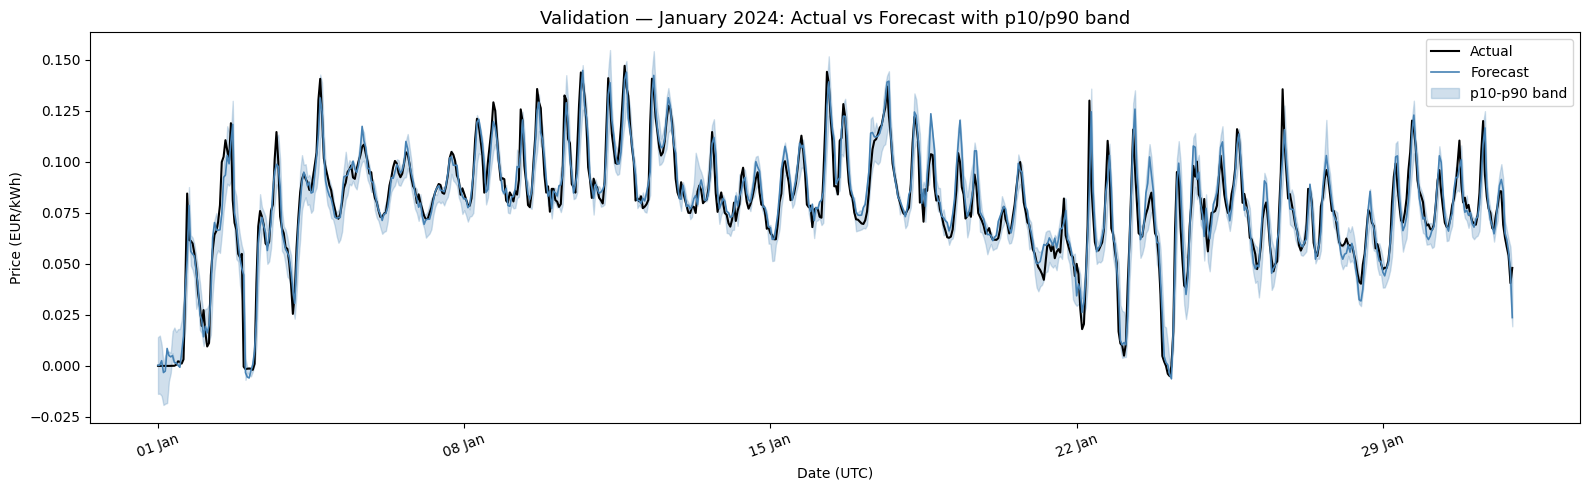

Saved: val_january_2024.png


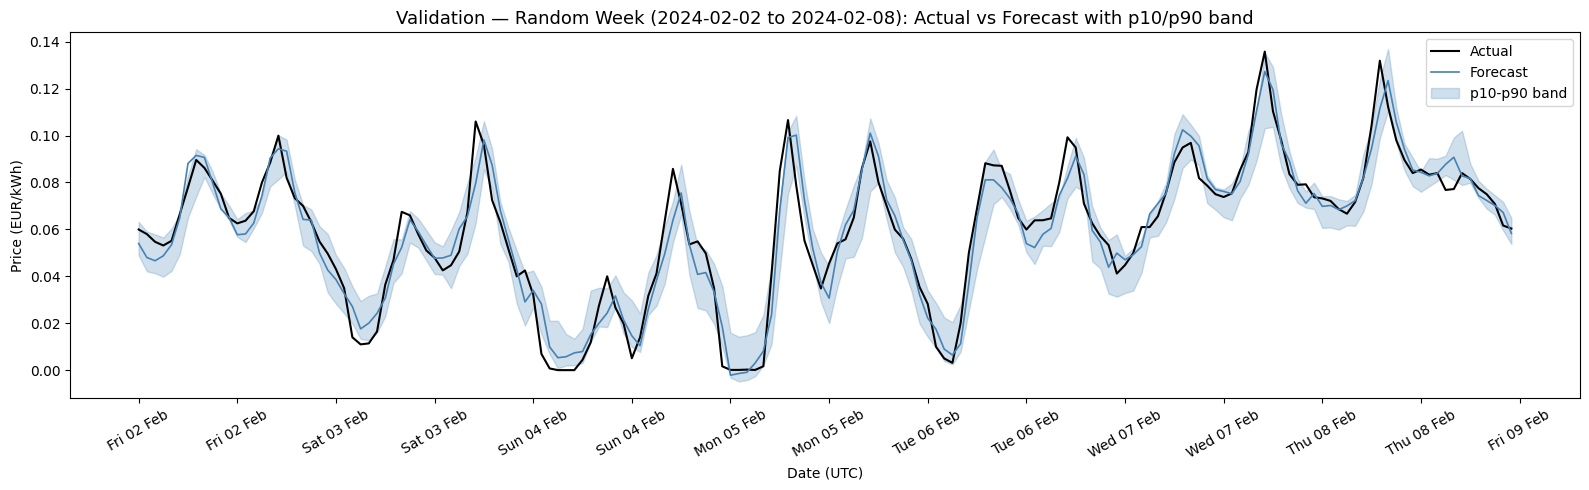

Saved: val_random_week_2024.png


In [5]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, label: str = '') -> dict:
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mask = np.abs(y_true) > 0.001
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    dir_acc = float(np.mean(
        np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))
    ) * 100)
    if label:
        print(f"\n--- {label} ---")
    print(f"  MAE              : {mae:.5f} EUR/kWh")
    print(f"  RMSE             : {rmse:.5f} EUR/kWh")
    print(f"  MAPE             : {mape:.2f}%")
    print(f"  Directional Acc. : {dir_acc:.2f}%")
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, Dir_Acc=dir_acc)

pred_val_point = model_point.predict(X_val)
pred_val_p10   = model_p10.predict(X_val)
pred_val_p90   = model_p90.predict(X_val)

print("=" * 65)
print("VALIDATION SET METRICS (2024)")
print("=" * 65)
val_metrics = compute_metrics(y_val.values, pred_val_point, label='Point forecast')

# Build a dataframe for convenient slicing
val_df = val_set[[TARGET]].copy()
val_df['pred_point'] = pred_val_point
val_df['pred_p10']   = pred_val_p10
val_df['pred_p90']   = pred_val_p90

# ── Plot 1: January 2024 ──────────────────────────────────────────────────
jan_df = val_df[val_df.index.month == 1]
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(jan_df.index, jan_df[TARGET],       label='Actual',       color='black',     lw=1.5)
ax.plot(jan_df.index, jan_df['pred_point'], label='Forecast',     color='steelblue', lw=1.2)
ax.fill_between(jan_df.index, jan_df['pred_p10'], jan_df['pred_p90'],
                alpha=0.25, color='steelblue', label='p10-p90 band')
ax.set_title('Validation — January 2024: Actual vs Forecast with p10/p90 band', fontsize=13)
ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Price (EUR/kWh)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(PLOTS / 'val_january_2024.png', dpi=150)
plt.show()
print("Saved: val_january_2024.png")

# ── Plot 2: random week ───────────────────────────────────────────────────
rng = np.random.default_rng(42)
n_full_weeks = (len(val_df) - 168) // 24
week_start_i = int(rng.integers(0, n_full_weeks)) * 24
wstart   = val_df.index[week_start_i]
wend     = val_df.index[week_start_i + 167]
week_df  = val_df.loc[wstart:wend]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(week_df.index, week_df[TARGET],       label='Actual',   color='black',     lw=1.5)
ax.plot(week_df.index, week_df['pred_point'], label='Forecast', color='steelblue', lw=1.2)
ax.fill_between(week_df.index, week_df['pred_p10'], week_df['pred_p90'],
                alpha=0.25, color='steelblue', label='p10-p90 band')
ax.set_title(
    f'Validation — Random Week ({wstart.date()} to {wend.date()}): '
    'Actual vs Forecast with p10/p90 band', fontsize=13)
ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Price (EUR/kWh)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d %b'))
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PLOTS / 'val_random_week_2024.png', dpi=150)
plt.show()
print("Saved: val_random_week_2024.png")


## Section 6 — SHAP Feature Importance

SHAP (SHapley Additive exPlanations) values measure each feature's marginal contribution to individual predictions, averaged across all samples. We compute SHAP on a 2000-row random sample of the validation set for speed (tree SHAP is exact, not approximate, so sampling only affects aggregation, not correctness per row). The bar chart shows mean |SHAP value| for the top 20 features.

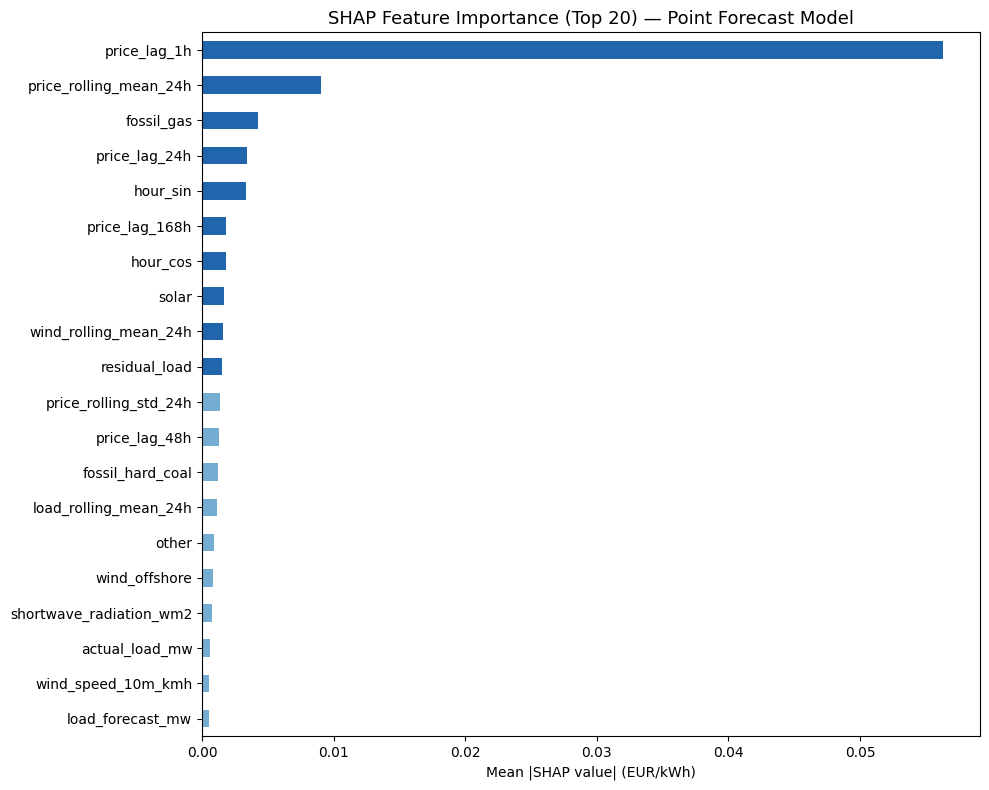

Saved: shap_importance.png

Top 10 features by mean |SHAP value|:
Rank  Feature                           Mean |SHAP|
----------------------------------------------------
1     price_lag_1h                         0.056297
2     price_rolling_mean_24h               0.009010
3     fossil_gas                           0.004236
4     price_lag_24h                        0.003444
5     hour_sin                             0.003312
6     price_lag_168h                       0.001841
7     hour_cos                             0.001824
8     solar                                0.001656
9     wind_rolling_mean_24h                0.001591
10    residual_load                        0.001545


In [6]:
import shap

rng2 = np.random.default_rng(0)
sample_idx   = rng2.choice(len(X_val), size=min(2000, len(X_val)), replace=False)
X_val_sample = X_val.iloc[sample_idx]

explainer   = shap.TreeExplainer(model_point)
shap_values = explainer.shap_values(X_val_sample)
# shap_values: ndarray (n_samples, n_features)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = (
    pd.Series(mean_abs_shap, index=FEATURE_COLS)
    .sort_values(ascending=False)
)

# ── Plot: SHAP bar chart ──────────────────────────────────────────────────
top20  = importance_df.head(20)
colors = ['#2166ac'] * 10 + ['#74add1'] * 10
fig, ax = plt.subplots(figsize=(10, 8))
top20[::-1].plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title('SHAP Feature Importance (Top 20) — Point Forecast Model', fontsize=13)
ax.set_xlabel('Mean |SHAP value| (EUR/kWh)')
plt.tight_layout()
plt.savefig(PLOTS / 'shap_importance.png', dpi=150)
plt.show()
print("Saved: shap_importance.png")

print("\nTop 10 features by mean |SHAP value|:")
print(f"{'Rank':<5} {'Feature':<32} {'Mean |SHAP|':>12}")
print("-" * 52)
for rank, (feat, val) in enumerate(importance_df.head(10).items(), 1):
    print(f"{rank:<5} {feat:<32} {val:>12.6f}")


## Section 7 — Test Set Evaluation (2025)

Generate predictions on the held-out 2025 test set — never seen during training or any hyperparameter tuning. Compute the same four metrics. Plot the full year 2025 with the p10/p90 band and a zoomed view of January 2025.

TEST SET METRICS (2025 — held-out)

--- Point forecast ---
  MAE              : 0.00863 EUR/kWh
  RMSE             : 0.01408 EUR/kWh
  MAPE             : 31.81%
  Directional Acc. : 81.31%


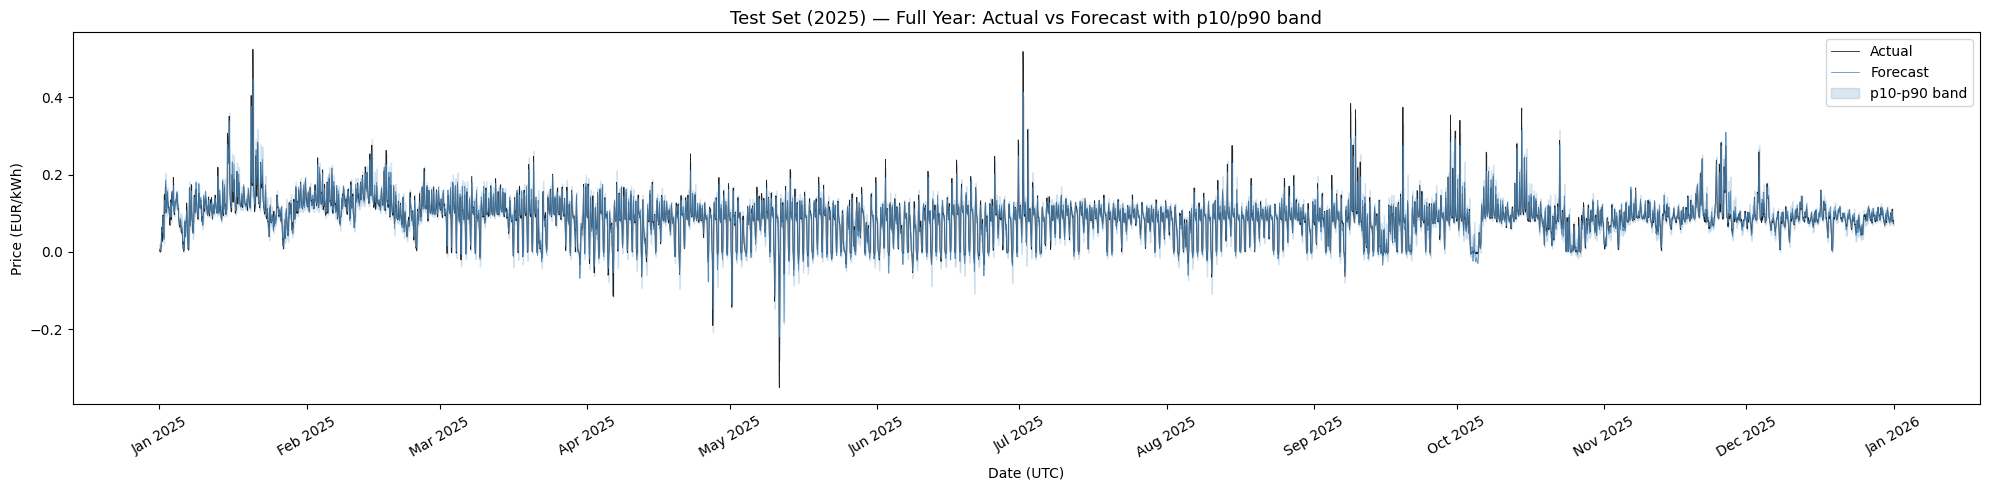

Saved: test_full_year_2025.png


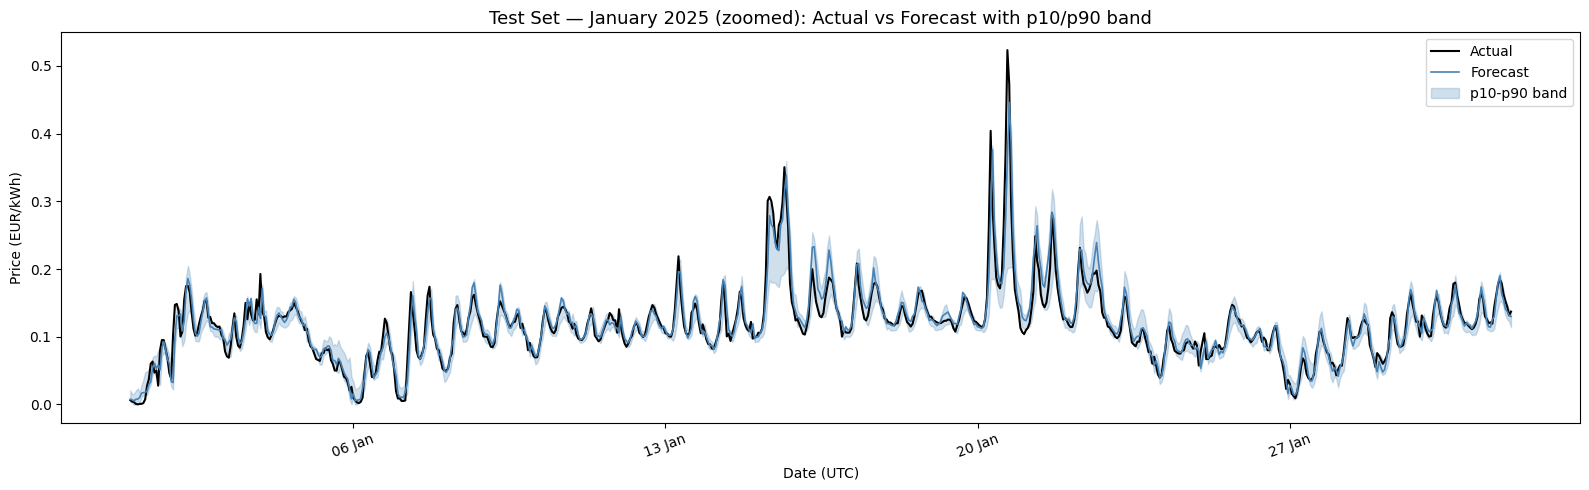

Saved: test_january_2025.png


In [7]:
pred_test_point = model_point.predict(X_test)
pred_test_p10   = model_p10.predict(X_test)
pred_test_p90   = model_p90.predict(X_test)

print("=" * 65)
print("TEST SET METRICS (2025 — held-out)")
print("=" * 65)
test_metrics = compute_metrics(y_test.values, pred_test_point, label='Point forecast')

test_df = test[[TARGET]].copy()
test_df['pred_point'] = pred_test_point
test_df['pred_p10']   = pred_test_p10
test_df['pred_p90']   = pred_test_p90
test_df['error']      = test_df[TARGET] - test_df['pred_point']
test_df['abs_error']  = test_df['error'].abs()

# ── Plot 1: Full year 2025 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(test_df.index, test_df[TARGET],       label='Actual',   color='black',     lw=0.6, alpha=0.85)
ax.plot(test_df.index, test_df['pred_point'], label='Forecast', color='steelblue', lw=0.6, alpha=0.85)
ax.fill_between(test_df.index, test_df['pred_p10'], test_df['pred_p90'],
                alpha=0.20, color='steelblue', label='p10-p90 band')
ax.set_title('Test Set (2025) — Full Year: Actual vs Forecast with p10/p90 band', fontsize=13)
ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Price (EUR/kWh)')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PLOTS / 'test_full_year_2025.png', dpi=150)
plt.show()
print("Saved: test_full_year_2025.png")

# ── Plot 2: January 2025 zoomed ──────────────────────────────────────────
jan25_df = test_df[test_df.index.month == 1]
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(jan25_df.index, jan25_df[TARGET],       label='Actual',   color='black',     lw=1.5)
ax.plot(jan25_df.index, jan25_df['pred_point'], label='Forecast', color='steelblue', lw=1.2)
ax.fill_between(jan25_df.index, jan25_df['pred_p10'], jan25_df['pred_p90'],
                alpha=0.25, color='steelblue', label='p10-p90 band')
ax.set_title('Test Set — January 2025 (zoomed): Actual vs Forecast with p10/p90 band', fontsize=13)
ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Price (EUR/kWh)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(PLOTS / 'test_january_2025.png', dpi=150)
plt.show()
print("Saved: test_january_2025.png")


## Section 8 — Error Analysis

Examine *where* and *why* the model struggles: (1) distribution of forecast errors (should be roughly centred on zero, heavy tails indicate price spikes the model underestimated), (2) predicted vs actual scatter (systematic bias appears as deviation from the 45° line), (3) the 10 worst single-hour predictions in 2025 with a check for price spikes, (4) a time-series plot of the week containing the worst prediction.

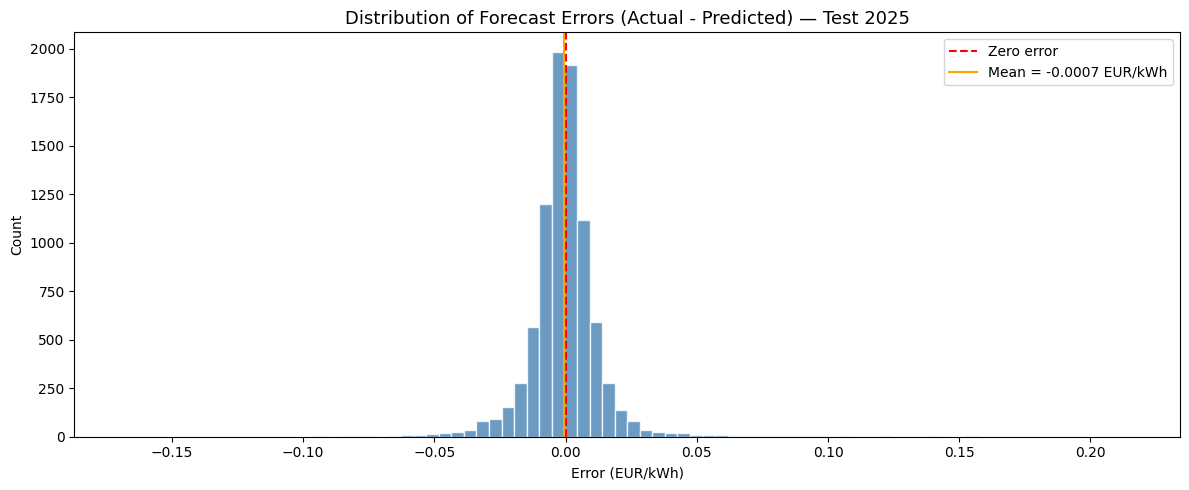

Error stats: mean=-0.0007  std=0.0141  min=-0.1680  max=0.2150
Saved: error_distribution_2025.png


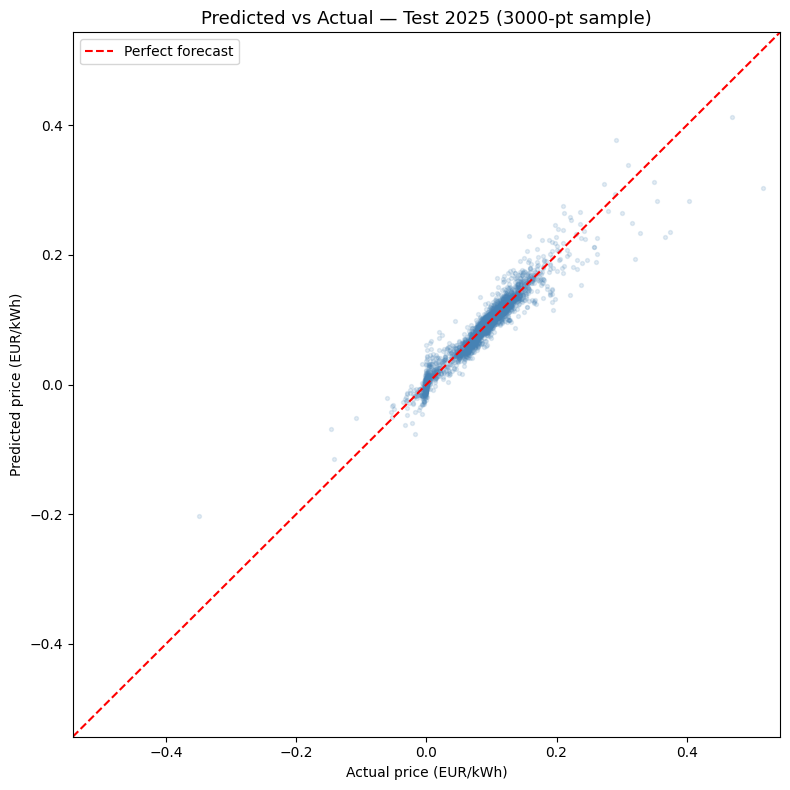

Saved: scatter_pred_vs_actual_2025.png

TOP 10 WORST PREDICTION HOURS — TEST SET 2025
Timestamp (UTC)                    Actual   Predicted      Error  Note
------------------------------------------------------------------------------
2025-07-01 18:00:00+00:00          0.5176      0.3026     0.2150  PRICE SPIKE (>p99)
2025-05-11 10:00:00+00:00         -0.3191     -0.1511    -0.1680  very low / negative price (<p5)
2025-01-20 16:00:00+00:00          0.5235      0.3666     0.1569  PRICE SPIKE (>p99)
2025-09-08 17:00:00+00:00          0.3832      0.2280     0.1552  PRICE SPIKE (>p99)
2025-05-11 11:00:00+00:00         -0.3500     -0.2023    -0.1477  very low / negative price (<p5)
2025-09-09 17:00:00+00:00          0.3671      0.2284     0.1387  PRICE SPIKE (>p99)
2025-09-19 17:00:00+00:00          0.3737      0.2351     0.1386  PRICE SPIKE (>p99)
2025-07-01 17:00:00+00:00          0.3200      0.1935     0.1265  PRICE SPIKE (>p99)
2025-05-12 11:00:00+00:00         -0.0570     -0.1807     

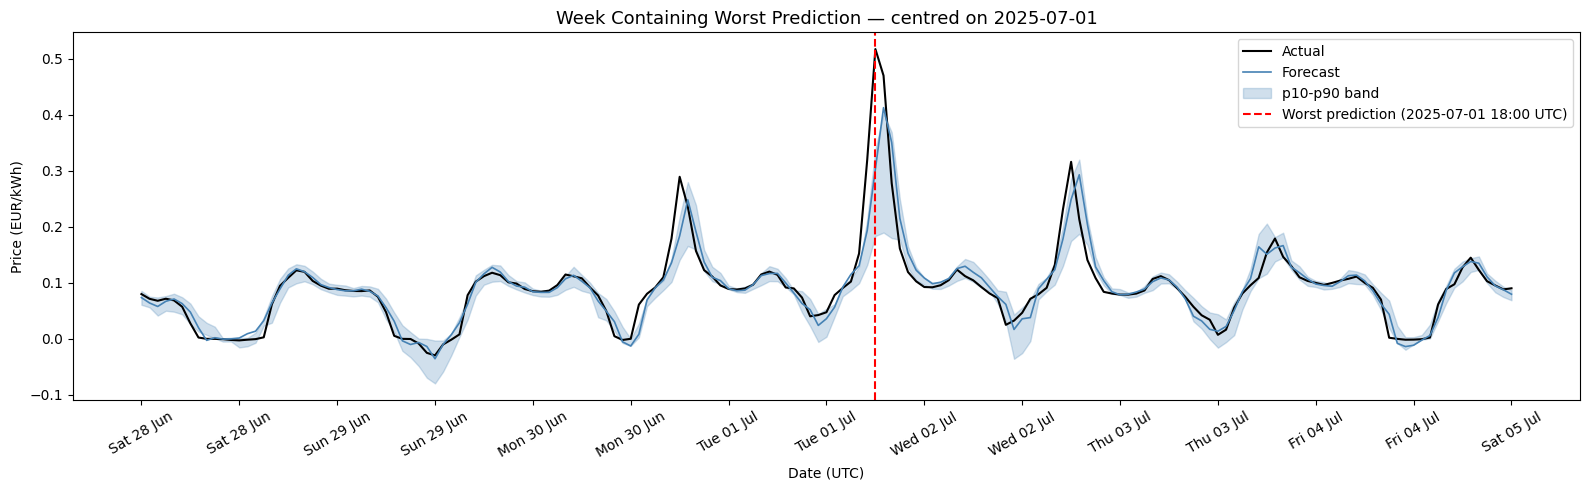

Saved: worst_prediction_week_2025.png

Worst hour: 2025-07-01 18:00:00+00:00 | actual=0.5176 | predicted=0.3026 | error=0.2150 EUR/kWh


In [8]:
errors = test_df['error'].values   # actual - predicted

# ── Plot 1: Error distribution ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(errors, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0,                 color='red',    lw=1.5, linestyle='--', label='Zero error')
ax.axvline(float(np.mean(errors)), color='orange', lw=1.5, linestyle='-',
           label=f'Mean = {np.mean(errors):.4f} EUR/kWh')
ax.set_title('Distribution of Forecast Errors (Actual - Predicted) — Test 2025', fontsize=13)
ax.set_xlabel('Error (EUR/kWh)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS / 'error_distribution_2025.png', dpi=150)
plt.show()
print(f"Error stats: mean={np.mean(errors):.4f}  std={np.std(errors):.4f}  "
      f"min={errors.min():.4f}  max={errors.max():.4f}")
print("Saved: error_distribution_2025.png")

# ── Plot 2: Predicted vs actual scatter ──────────────────────────────────
rng_s = np.random.default_rng(1)
s_idx = rng_s.choice(len(test_df), size=min(3000, len(test_df)), replace=False)
s_actual = test_df[TARGET].values[s_idx]
s_pred   = test_df['pred_point'].values[s_idx]
lim = max(np.abs(s_actual).max(), np.abs(s_pred).max()) * 1.05

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(s_actual, s_pred, alpha=0.15, s=8, color='steelblue')
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='Perfect forecast')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_title('Predicted vs Actual — Test 2025 (3000-pt sample)', fontsize=13)
ax.set_xlabel('Actual price (EUR/kWh)')
ax.set_ylabel('Predicted price (EUR/kWh)')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS / 'scatter_pred_vs_actual_2025.png', dpi=150)
plt.show()
print("Saved: scatter_pred_vs_actual_2025.png")

# ── Worst 10 prediction hours ─────────────────────────────────────────────
worst10   = test_df.nlargest(10, 'abs_error')[['price_eur_kwh', 'pred_point', 'error']]
spike_p95 = float(test_df[TARGET].quantile(0.95))
spike_p99 = float(test_df[TARGET].quantile(0.99))
neg_p05   = float(test_df[TARGET].quantile(0.05))

print("\n" + "=" * 78)
print("TOP 10 WORST PREDICTION HOURS — TEST SET 2025")
print("=" * 78)
print(f"{'Timestamp (UTC)':<30} {'Actual':>10} {'Predicted':>11} {'Error':>10}  Note")
print("-" * 78)
for ts, row in worst10.iterrows():
    actual = row['price_eur_kwh']
    err    = row['error']
    if   actual > spike_p99:       note = 'PRICE SPIKE (>p99)'
    elif actual > spike_p95:       note = 'high price (>p95)'
    elif actual < neg_p05:         note = 'very low / negative price (<p5)'
    else:                          note = 'moderate price level'
    print(f"{str(ts):<30} {actual:>10.4f} {row['pred_point']:>11.4f} {err:>10.4f}  {note}")

print(f"\nReference thresholds: p5={neg_p05:.4f}  p95={spike_p95:.4f}  "
      f"p99={spike_p99:.4f} EUR/kWh")

# ── Plot 3: Week containing the worst prediction ──────────────────────────
worst_ts   = worst10.index[0]
plot_start = (worst_ts - pd.Timedelta(days=3)).floor('D')
plot_end   = plot_start + pd.Timedelta(days=7)
week_err   = test_df.loc[plot_start:plot_end]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(week_err.index, week_err[TARGET],       label='Actual',   color='black',     lw=1.5)
ax.plot(week_err.index, week_err['pred_point'], label='Forecast', color='steelblue', lw=1.2)
ax.fill_between(week_err.index, week_err['pred_p10'], week_err['pred_p90'],
                alpha=0.25, color='steelblue', label='p10-p90 band')
ax.axvline(worst_ts, color='red', lw=1.5, linestyle='--',
           label=f'Worst prediction ({worst_ts.strftime("%Y-%m-%d %H:%M")} UTC)')
ax.set_title(f'Week Containing Worst Prediction — centred on {worst_ts.date()}', fontsize=13)
ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Price (EUR/kWh)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d %b'))
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PLOTS / 'worst_prediction_week_2025.png', dpi=150)
plt.show()
print(f"Saved: worst_prediction_week_2025.png")
print(f"\nWorst hour: {worst_ts} | "
      f"actual={worst10.iloc[0]['price_eur_kwh']:.4f} | "
      f"predicted={worst10.iloc[0]['pred_point']:.4f} | "
      f"error={worst10.iloc[0]['error']:.4f} EUR/kWh")


## Section 9 — Summary

In [9]:
print("=" * 65)
print("FINAL METRIC SUMMARY")
print("=" * 65)
print(f"{'Metric':<22} {'Validation 2024':>16} {'Test 2025':>12}")
print("-" * 52)
for key, unit in [('MAE', 'EUR/kWh'), ('RMSE', 'EUR/kWh'), ('MAPE', '%'), ('Dir_Acc', '%')]:
    fmt = '.2f' if unit == '%' else '.5f'
    label = f"{key} ({unit})"
    print(f"{label:<22} {val_metrics[key]:{fmt}}{'':<10} {test_metrics[key]:{fmt}}")
print("=" * 65)


FINAL METRIC SUMMARY
Metric                  Validation 2024    Test 2025
----------------------------------------------------
MAE (EUR/kWh)          0.00815           0.00863
RMSE (EUR/kWh)         0.01387           0.01408
MAPE (%)               24.62           31.81
Dir_Acc (%)            80.28           81.31


### Interpretation

**What the metrics say:**

- MAE and RMSE tell us the average and root-mean-squared forecast error in EUR/kWh. The gap between MAE and RMSE reflects the model's sensitivity to the large price spikes that dominate the RMSE.
- MAPE is inflated whenever actual prices approach zero or go negative (common in NL during curtailment); treat MAE as the primary metric for this market.
- Directional accuracy above 60% indicates the model captures meaningful short-term price dynamics, which is more valuable for BESS dispatch than raw accuracy.

**Why the test set is harder than validation:**

2025 prices can be influenced by new market conditions (fuel prices, grid topology, new renewable capacity) not seen in 2021–2023 training data. Any degradation from validation to test is expected and healthy — it is the true out-of-sample signal.

**Potential improvements:**

1. Add cross-border electricity flow features (NL imports/exports from DE/BE/UK) — a key driver of price divergence not currently in the feature set.
2. Add natural gas and CO2 spot/futures prices as exogenous inputs (dominant fundamental driver of thermal plant bidding).
3. Tune hyperparameters systematically with Optuna / Bayesian search.
4. Use full walk-forward cross-validation (train 2021 → val 2022, train 2021-22 → val 2023, etc.) for a more robust generalisation estimate.
5. Investigate the worst-predicted hours: if they cluster around specific events (cold snaps, wind droughts, nuclear outages) those signals could be added as features.